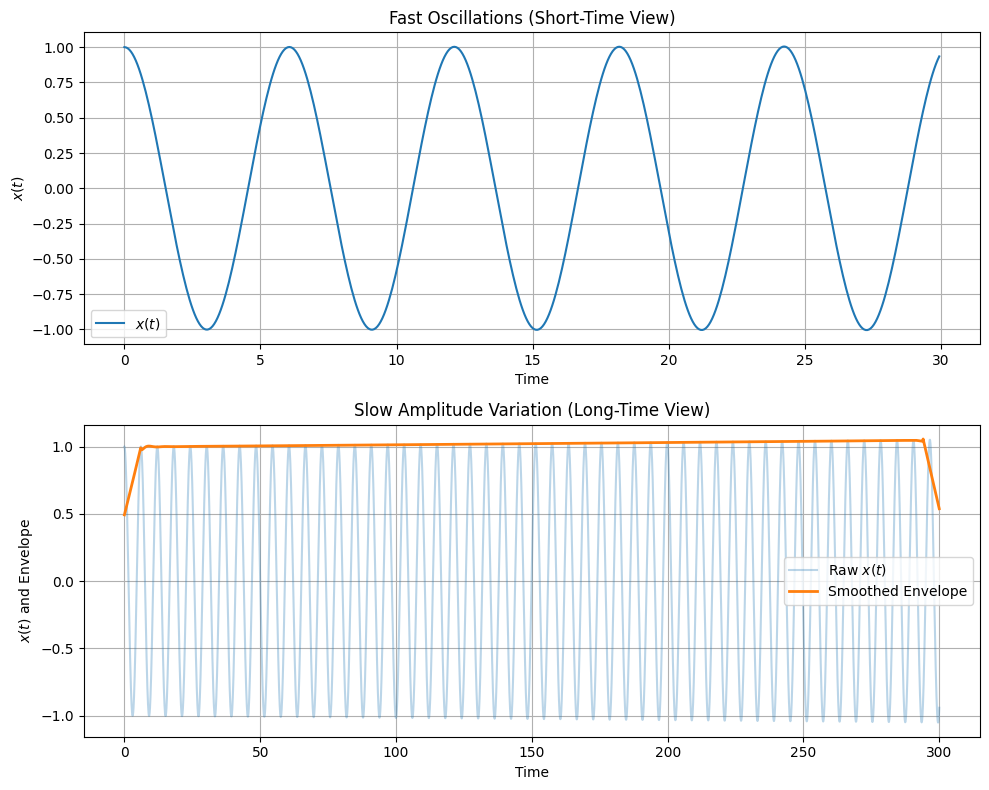

In [1]:
#!/usr/bin/env python
# coding: utf-8

# # Visualization of Time Scale Separation in a Weakly Nonlinear Duffing Oscillator
# 
# This Jupyter notebook demonstrates the separation of timescales in a weakly nonlinear Duffing oscillator:
# \[
# \ddot{x} + x + \epsilon x^3 = 0, \quad \epsilon \ll 1.
# \]
# 
# The Duffing oscillator can be viewed as a weak perturbation of the simple harmonic oscillator \(\ddot{x} + x = 0.\) In the small-\(\epsilon\) limit, the solution resembles a harmonic oscillator whose amplitude and phase vary very slowly over time. 
# 
# We will:
# 1. Numerically integrate the Duffing oscillator equation for a small \(\epsilon\).
# 2. Show that the solution \(x(t)\) undergoes rapid oscillations on a timescale \(\mathcal{O}(1)\).
# 3. Extract and visualize the slowly varying amplitude envelope by a time-averaging method.
# 
# By plotting both the raw solution and its slowly varying envelope, we will illustrate the separation of fast and slow dynamics.

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ## Parameters and Setup
# Choose a small epsilon to illustrate the perturbation.
epsilon = 0.1
# Initial conditions: Let's start with some initial amplitude.
x0 = 1.0   # initial displacement
y0 = 0.0   # initial velocity

# Time domain: 
# We'll integrate over a relatively long time to see the slow evolution of amplitude.
t_start = 0.0
t_end = 300.0
t_eval = np.linspace(t_start, t_end, 5000)  # sufficiently fine resolution

# ## Duffing Oscillator ODE
# The system is:
# \[
# \dot{x} = y,\quad \dot{y} = -x - \epsilon x^3.
# \]

def duffing(t, XY, epsilon=epsilon):
    x, y = XY
    dxdt = y
    dydt = -x - epsilon*x**3
    return [dxdt, dydt]

# Solve the ODE
sol = solve_ivp(duffing, [t_start, t_end], [x0, y0], t_eval=t_eval, args=(epsilon,))

t = sol.t
x = sol.y[0,:]
y = sol.y[1,:]

# ## Extracting the Envelope
# The fast oscillations occur roughly with frequency near 1 (for small amplitude).
# We can try to extract a slowly varying amplitude by:
# 1. Using the Hilbert transform (from `scipy.signal`) to get an analytic signal and thus the instantaneous amplitude.
#    OR
# 2. Using a moving window RMS to approximate the envelope.
#
# Here, let's use the Hilbert transform to find the envelope of x(t).

from scipy.signal import hilbert

analytic_signal = hilbert(x)
amplitude_envelope = np.abs(analytic_signal)

# To highlight the slow timescale, we can also smooth the envelope further.
# A simple approach: moving average over a window corresponding to several oscillation periods.
window_size = 200  # number of points in moving average ~ smoothing
envelope_smooth = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# ## Visualization
# We'll create two plots:
# 1. A short-time zoomed-in view showing the fast oscillations.
# 2. A long-time view showing the slowly varying amplitude envelope.

fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=False)

# Plot a short-time segment to see fast oscillations
t_zoom_start = 0
t_zoom_end = 30
mask_zoom = (t >= t_zoom_start) & (t <= t_zoom_end)

axes[0].plot(t[mask_zoom], x[mask_zoom], label='$x(t)$')
axes[0].set_title('Fast Oscillations (Short-Time View)')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('$x(t)$')
axes[0].legend()
axes[0].grid(True)

# Long-time view to see envelope
axes[1].plot(t, x, color='C0', alpha=0.3, label='Raw $x(t)$')
axes[1].plot(t, envelope_smooth, color='C1', linewidth=2, label='Smoothed Envelope')
axes[1].set_title('Slow Amplitude Variation (Long-Time View)')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('$x(t)$ and Envelope')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

